# Hindsight CORD CBA — Dual-Track Receipt Concept Binding

**Goal**: Measure concept-binding accuracy on Indonesian receipts using the [CORD](https://github.com/clovaai/cord) benchmark (1000 receipts, 30 semantic classes, CC-BY-4.0).

**Why pivot from paystubs?** The paystub v2 experiment proved the two-stage pipeline + value-first scoring *works* (detected 1–5 real misbindings), but paystubs lack sufficient concept ambiguity — only 1–5 misbindings out of ~700 field evaluations. Receipts have more confusable fields:
- `subtotal_price` vs `total_price` vs `tax_price`
- `cashprice` vs `changeprice`
- `menuqty_cnt` vs `itemsubtotal_cnt`

Indonesian labels + multiple numeric amount fields = high concept binding challenge.

**Dual-track design**:
- **Track A** (Tesseract + LLM): Tesseract OCR → LLM maps raw text to concepts
- **Track B** (LLM Vision): LLM sees the image directly → extracts and maps in one step

Both tracks use array output `[{label, value, concept}]` and value-first scoring (proven in paystub v2).

In [1]:
# Cell 1: Setup & Dependencies

!pip install anthropic openai pyyaml pytesseract Pillow datasets -q

import anthropic, openai, json, time, os, re, random, base64
import yaml
import pytesseract
from PIL import Image
from datasets import load_dataset
from collections import defaultdict, Counter
from datetime import datetime
from google.colab import userdata # Import userdata

# API keys from environment
ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY") # Use userdata.get
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY") # Use userdata.get

assert ANTHROPIC_API_KEY, "Set ANTHROPIC_API_KEY environment variable in Colab Secrets"
assert OPENAI_API_KEY, "Set OPENAI_API_KEY environment variable in Colab Secrets"

# Verify Tesseract
tess_version = pytesseract.get_tesseract_version()
print(f"Tesseract version: {tess_version}")
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.9/635.9 kB 13.5 MB/s eta 0:00:00
Tesseract version: 4.1.1
Setup complete.


In [2]:
# Cell 2: Load CORD Dataset & Build GT

dataset = load_dataset("naver-clova-ix/cord-v2", split="test")
print(f"CORD test set: {len(dataset)} receipts")

# 13 singleton eval concepts (most confusable fields)
EVAL_CONCEPTS = [
    "subtotal_price",     # Pre-tax subtotal
    "tax_price",          # Tax amount
    "total_price",        # Final total
    "cashprice",          # Cash tendered / amount paid
    "changeprice",        # Change returned
    "creditcardprice",    # Credit card amount
    "emoneyprice",        # E-money amount
    "otherprice",         # Other payment amount
    "menuqty_cnt",        # Total distinct menu items count
    "itemsubtotal_cnt",   # Total item count (with quantities)
    "total_etc",          # Additional total info (service charge, discount)
    "subtotal_etc",       # Additional subtotal info
    "tax_etc",            # Additional tax info
]


def flatten_cord_gt(gt_parse):
    """Flatten CORD nested GT to {concept: value} dict for eval concepts only."""
    flat = {}
    for section_key, section_val in gt_parse.items():
        if isinstance(section_val, dict):
            for field_key, field_val in section_val.items():
                if field_key in EVAL_CONCEPTS and field_key not in flat:
                    if isinstance(field_val, str) and field_val.strip():
                        flat[field_key] = field_val.strip()
                    elif isinstance(field_val, list):
                        # Some fields are lists — take first non-empty
                        for v in field_val:
                            if isinstance(v, str) and v.strip():
                                flat[field_key] = v.strip()
                                break
        elif isinstance(section_val, list):
            # Handle list-of-dicts structure (e.g., menu items)
            for item in section_val:
                if isinstance(item, dict):
                    for field_key, field_val in item.items():
                        if field_key in EVAL_CONCEPTS and field_key not in flat:
                            if isinstance(field_val, str) and field_val.strip():
                                flat[field_key] = field_val.strip()
    return flat


# Parse GT for all receipts
cord_data = []
concept_coverage = Counter()

for i, sample in enumerate(dataset):
    gt_raw = json.loads(sample["ground_truth"])
    gt_parse = gt_raw.get("gt_parse", {})
    flat_gt = flatten_cord_gt(gt_parse)

    for concept in flat_gt:
        concept_coverage[concept] += 1

    cord_data.append({
        "index": i,
        "image": sample["image"],  # PIL Image
        "gt_parse": gt_parse,
        "flat_gt": flat_gt,
        "n_eval_concepts": len(flat_gt),
    })

# Filter: at least 3 eval concepts present
qualified = [d for d in cord_data if d["n_eval_concepts"] >= 3]
print(f"\nReceipts with >= 3 eval concepts: {len(qualified)} / {len(cord_data)}")

print(f"\nConcept coverage across full test set:")
for concept in EVAL_CONCEPTS:
    count = concept_coverage.get(concept, 0)
    print(f"  {concept}: {count} receipts")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00004-7dbbe248962764(…):   0%|          | 0.00/441M [00:00<?, ?B/s]

...

data/test-00000-of-00001-9c204eb3f4e1179(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

CORD test set: 100 receipts

Receipts with >= 3 eval concepts: 93 / 100

Concept coverage across full test set:
  subtotal_price: 65 receipts
  tax_price: 43 receipts
  total_price: 95 receipts
  cashprice: 67 receipts
  changeprice: 56 receipts
  creditcardprice: 16 receipts
  emoneyprice: 1 receipts
  otherprice: 0 receipts
  menuqty_cnt: 29 receipts
  itemsubtotal_cnt: 0 receipts
  total_etc: 3 receipts
  subtotal_etc: 0 receipts
  tax_etc: 0 receipts


In [3]:
# Cell 3: Ontology & Prompts

# Receipt ontology (3 families of confusable concepts)
RECEIPT_ONTOLOGY = {
    "families": {
        "amounts": ["subtotal_price", "tax_price", "total_price", "total_etc", "subtotal_etc", "tax_etc"],
        "payment": ["cashprice", "changeprice", "creditcardprice", "emoneyprice", "otherprice"],
        "counts":  ["menuqty_cnt", "itemsubtotal_cnt"],
    }
}

# Build concept_to_family map for scoring
concept_to_family = {}
for family_name, concepts in RECEIPT_ONTOLOGY["families"].items():
    for concept in concepts:
        concept_to_family[concept] = family_name

# Wrap into ontology dict matching score functions' expected format
ontology = {
    "concept_to_family": concept_to_family,
    "families": RECEIPT_ONTOLOGY["families"],
}

print(f"Ontology: {len(concept_to_family)} concepts across {len(RECEIPT_ONTOLOGY['families'])} families")
for fam, concepts in RECEIPT_ONTOLOGY["families"].items():
    print(f"  {fam}: {concepts}")

# --- Stage 2 Prompts ---

CONCEPT_LIST = ", ".join(EVAL_CONCEPTS)

# Track A: Tesseract + LLM (receives raw OCR text)
STAGE2_SYSTEM_OCR = f"""You are a data mapping system. Given raw OCR text from a receipt, identify fields and map each to the most appropriate canonical concept.

Canonical concepts:
{CONCEPT_LIST}

Return a JSON array of objects. Each object must have:
- "label": the field label as it appears in the OCR text
- "value": the corresponding value as it appears in the OCR text
- "concept": the canonical concept name from the list above

Rules:
- Only include fields that clearly match a canonical concept
- Each concept may appear at most once
- Do not fabricate values — only use text present in the OCR output
- Note: receipts may be in Indonesian (Bahasa Indonesia)"""

# Track B: LLM Vision (receives image directly)
STAGE2_SYSTEM_VISION = f"""You are a receipt extraction and mapping system. Look at this receipt image and extract fields, mapping each to the most appropriate canonical concept.

Canonical concepts:
{CONCEPT_LIST}

Return a JSON array of objects. Each object must have:
- "label": the field label as shown on the receipt
- "value": the corresponding value as shown on the receipt
- "concept": the canonical concept name from the list above

Rules:
- Only include fields that clearly match a canonical concept
- Each concept may appear at most once
- Do not fabricate values — only use text visible on the receipt
- Note: receipts may be in Indonesian (Bahasa Indonesia)"""

print(f"\nTrack A prompt (OCR): {len(STAGE2_SYSTEM_OCR)} chars")
print(f"Track B prompt (Vision): {len(STAGE2_SYSTEM_VISION)} chars")
print(f"Output format: array of {{label, value, concept}}")

Ontology: 13 concepts across 3 families
  amounts: ['subtotal_price', 'tax_price', 'total_price', 'total_etc', 'subtotal_etc', 'tax_etc']
  payment: ['cashprice', 'changeprice', 'creditcardprice', 'emoneyprice', 'otherprice']
  counts: ['menuqty_cnt', 'itemsubtotal_cnt']

Track A prompt (OCR): 799 chars
Track B prompt (Vision): 798 chars
Output format: array of {label, value, concept}


In [4]:
# Cell 4: Sampling & Image Export

random.seed(42)

# Sample up to 100 qualified receipts
if len(qualified) > 100:
    sampled = random.sample(qualified, 100)
else:
    sampled = qualified[:]

# Sort by index for deterministic ordering
sampled.sort(key=lambda d: d["index"])

print(f"Sampled {len(sampled)} receipts from {len(qualified)} qualified ({len(cord_data)} total)")

# Concept distribution in sample
sample_concept_counts = Counter()
for d in sampled:
    for c in d["flat_gt"]:
        sample_concept_counts[c] += 1

print(f"\nConcept coverage in sample:")
for concept in EVAL_CONCEPTS:
    count = sample_concept_counts.get(concept, 0)
    print(f"  {concept}: {count}")

# Eval concept count distribution
n_concept_dist = Counter(d["n_eval_concepts"] for d in sampled)
print(f"\nEval concepts per receipt:")
for n, count in sorted(n_concept_dist.items()):
    print(f"  {n} concepts: {count} receipts")

# Save images to /tmp/cord_images/ for Tesseract
IMAGE_DIR = "/tmp/cord_images"
os.makedirs(IMAGE_DIR, exist_ok=True)

for d in sampled:
    img_path = os.path.join(IMAGE_DIR, f"receipt_{d['index']:04d}.png")
    d["image_path"] = img_path
    if not os.path.exists(img_path):
        d["image"].save(img_path)

print(f"\nImages saved to {IMAGE_DIR}/")

Sampled 93 receipts from 93 qualified (100 total)

Concept coverage in sample:
  subtotal_price: 64
  tax_price: 43
  total_price: 91
  cashprice: 64
  changeprice: 56
  creditcardprice: 14
  emoneyprice: 1
  otherprice: 0
  menuqty_cnt: 27
  itemsubtotal_cnt: 0
  total_etc: 3
  subtotal_etc: 0
  tax_etc: 0

Eval concepts per receipt:
  3 concepts: 40 receipts
  4 concepts: 27 receipts
  5 concepts: 21 receipts
  6 concepts: 5 receipts

Images saved to /tmp/cord_images/


In [5]:
# Cell 5: Scoring Functions (value-first matching — reused from paystub v2)

def normalize_value(v):
    """Normalize an extracted value for comparison.

    Handles Indonesian number format: '.' as thousands separator.
    E.g., '45.000' = 45000, '1.500.000' = 1500000.
    """
    v = str(v).lower().strip()
    # Strip currency symbols and whitespace
    v = v.replace("rp", "").replace("rp.", "").replace("idr", "")
    v = v.replace("$", "").replace(",", "").strip()
    v = re.sub(r"\s+", " ", v)

    # Indonesian thousands separator: dots between digit groups
    # '45.000' → '45000', '1.500.000' → '1500000'
    # But preserve actual decimals like '0.5'
    if re.fullmatch(r"\d{1,3}(\.\d{3})+", v):
        v = v.replace(".", "")

    # Strip trailing zeros on decimals
    if re.fullmatch(r"-?\d+\.\d+", v):
        v = v.rstrip("0").rstrip(".")

    return v


def cba_strict(predicted_concept, ground_truth_concept):
    """Binary concept-binding accuracy: 1.0 if match, 0.0 otherwise."""
    return 1.0 if predicted_concept == ground_truth_concept else 0.0


def cba_soft(predicted_concept, ground_truth_concept, ontology):
    """Partial-credit CBA: 1.0 exact, 0.5 same family, 0.0 otherwise."""
    if predicted_concept == ground_truth_concept:
        return 1.0
    c2f = ontology.get("concept_to_family", {})
    gt_family = c2f.get(ground_truth_concept)
    pred_family = c2f.get(predicted_concept)
    if gt_family is not None and gt_family == pred_family:
        return 0.5
    return 0.0


def score_field(gt_value, pred_value, gt_concept, pred_concept, ontology):
    """Score a single field extraction."""
    norm_gt = normalize_value(gt_value)
    norm_pred = normalize_value(pred_value)
    value_match = norm_gt == norm_pred

    # CBA is only meaningful when value was correctly extracted (protocol step v:
    # concept matched, value wrong → CBA=0, not CBA=1).
    if value_match:
        strict = cba_strict(pred_concept, gt_concept)
        soft = cba_soft(pred_concept, gt_concept, ontology)
    else:
        strict = 0.0
        soft = 0.0

    return {
        "value_match": value_match,
        "field_recall_contribution": 1.0 if value_match else 0.0,
        "cba_strict": strict,
        "cba_soft": soft,
        "is_misbinding": value_match and strict == 0.0,
        "gt_concept": gt_concept,
        "pred_concept": pred_concept,
        "gt_value": gt_value,
        "pred_value": pred_value,
    }


def score_document(ground_truth, predictions, ontology, eval_concepts=None):
    """Score all field extractions for a single document.

    Uses VALUE-FIRST matching:
    1. For each GT concept, search ALL predictions for a matching value
    2. Prefer exact concept match when same value appears under multiple keys
    3. If value found under wrong concept → misbinding
    4. If no value match, fall back to concept-key match (value miss)
    5. If neither → complete miss
    """
    if eval_concepts is not None:
        ground_truth = {k: v for k, v in ground_truth.items() if k in eval_concepts}

    per_field = []
    misbindings = []
    used_pred_keys = set()

    for gt_concept, gt_value in ground_truth.items():
        norm_gt = normalize_value(gt_value)

        # Value-first: search all predictions for this value
        matched_pred_concept = None
        for pk, pv in predictions.items():
            if pk in used_pred_keys:
                continue
            if normalize_value(pv) == norm_gt:
                if pk == gt_concept:
                    matched_pred_concept = pk
                    break  # Exact concept+value match — best case
                elif matched_pred_concept is None:
                    matched_pred_concept = pk  # First value match (possibly wrong concept)

        if matched_pred_concept is not None:
            pred_concept = matched_pred_concept
            pred_value = predictions[matched_pred_concept]
            used_pred_keys.add(matched_pred_concept)
        elif gt_concept in predictions and gt_concept not in used_pred_keys:
            pred_concept = gt_concept
            pred_value = predictions[gt_concept]
            used_pred_keys.add(gt_concept)
        else:
            pred_concept = "__MISSING__"
            pred_value = ""

        field_score = score_field(gt_value, pred_value, gt_concept, pred_concept, ontology)
        per_field.append(field_score)

        if field_score["is_misbinding"]:
            misbindings.append({
                "gt_concept": gt_concept,
                "pred_concept": pred_concept,
                "value": gt_value,
            })

    n = len(per_field)
    if n == 0:
        return {
            "field_recall": 0.0, "cba_strict": 0.0, "cba_soft": 0.0,
            "delta": 0.0, "n_fields": 0, "n_misbindings": 0,
            "misbindings": [], "per_field": [],
        }

    field_recall = sum(f["field_recall_contribution"] for f in per_field) / n
    cba_s = sum(f["cba_strict"] for f in per_field) / n
    cba_so = sum(f["cba_soft"] for f in per_field) / n

    return {
        "field_recall": round(field_recall, 6),
        "cba_strict": round(cba_s, 6),
        "cba_soft": round(cba_so, 6),
        "delta": round(field_recall - cba_s, 6),
        "n_fields": n,
        "n_misbindings": len(misbindings),
        "misbindings": misbindings,
        "per_field": per_field,
    }


# --- Confusion matrix helpers ---

def build_confusion_matrix(scored_documents):
    """Build NxN concept confusion matrix from scored documents."""
    concept_set = set(EVAL_CONCEPTS)
    pair_counts = defaultdict(int)

    for doc in scored_documents:
        for field in doc.get("per_field", []):
            gt_c = field["gt_concept"]
            pred_c = field["pred_concept"]
            concept_set.add(gt_c)
            if pred_c != "__MISSING__":
                concept_set.add(pred_c)
            pair_counts[(gt_c, pred_c)] += 1

    concepts = sorted(concept_set)
    idx = {c: i for i, c in enumerate(concepts)}
    n = len(concepts)

    matrix = [[0] * n for _ in range(n)]
    for (gt_c, pred_c), count in pair_counts.items():
        if gt_c in idx and pred_c in idx:
            matrix[idx[gt_c]][idx[pred_c]] += count

    families = {c: concept_to_family.get(c, "unknown") for c in concepts}
    return {"matrix": matrix, "concepts": concepts, "families": families}


def top_confusions(matrix_data, n=10):
    """Return top N most frequent off-diagonal confusions."""
    concepts = matrix_data["concepts"]
    matrix = matrix_data["matrix"]
    confusions = []
    for i, gt_c in enumerate(concepts):
        for j, pred_c in enumerate(concepts):
            if i != j and matrix[i][j] > 0:
                confusions.append((gt_c, pred_c, matrix[i][j]))
    confusions.sort(key=lambda x: x[2], reverse=True)
    return confusions[:n]


print("Scoring functions loaded (value-first matching).")

# Sanity checks
# 1. Correct binding
_test_gt = {"total_price": "50.000", "cashprice": "60.000"}
_test_pred = {"total_price": "50000", "cashprice": "60000"}
_test_score = score_document(_test_gt, _test_pred, ontology, eval_concepts=EVAL_CONCEPTS)
print(f"Sanity 1 (correct): field_recall={_test_score['field_recall']}, cba={_test_score['cba_strict']}, misbindings={_test_score['n_misbindings']}")
assert _test_score["field_recall"] == 1.0, "Expected perfect field_recall"
assert _test_score["n_misbindings"] == 0, "Expected 0 misbindings"

# 2. Swapped values → should detect misbinding
_test_gt2 = {"subtotal_price": "45.000", "total_price": "50.000"}
_test_pred2 = {"total_price": "45000", "subtotal_price": "50000"}
_test_score2 = score_document(_test_gt2, _test_pred2, ontology, eval_concepts=EVAL_CONCEPTS)
print(f"Sanity 2 (swap):    field_recall={_test_score2['field_recall']}, cba={_test_score2['cba_strict']}, misbindings={_test_score2['n_misbindings']}")
assert _test_score2["n_misbindings"] == 2, f"Expected 2 misbindings for swap, got {_test_score2['n_misbindings']}"
assert _test_score2["delta"] > 0, f"Expected positive delta for swap, got {_test_score2['delta']}"
print("  Swap detection works! delta > 0, misbindings = 2")

# 3. Indonesian number normalization
assert normalize_value("45.000") == "45000"
assert normalize_value("1.500.000") == "1500000"
assert normalize_value("Rp 45.000") == "45000"
assert normalize_value("0.5") == "0.5"  # Preserve actual decimal
print("  Indonesian number normalization works!")

Scoring functions loaded (value-first matching).
Sanity 1 (correct): field_f1=1.0, cba=1.0, misbindings=0
Sanity 2 (swap):    field_f1=1.0, cba=0.0, misbindings=2
  Swap detection works! delta > 0, misbindings = 2
  Indonesian number normalization works!


In [6]:
# Cell 6: Extraction Functions — Dual Track

MAX_RETRIES = 5
BASE_DELAY = 2  # seconds
MAX_IMAGE_BYTES = 4_500_000  # Stay under Anthropic's 5MB base64 limit


def _parse_json(raw):
    """Strip markdown fences and parse JSON."""
    raw = raw.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]
    return json.loads(raw)


def _retry_with_backoff(fn, max_retries=MAX_RETRIES, base_delay=BASE_DELAY):
    """Call fn() with exponential backoff on rate-limit (429) errors."""
    for attempt in range(max_retries):
        try:
            return fn()
        except Exception as e:
            is_rate_limit = "429" in str(e) or "rate_limit" in str(e).lower()
            if attempt < max_retries - 1:
                delay = base_delay * (2 ** attempt) if is_rate_limit else base_delay
                label = "Rate limited" if is_rate_limit else "Error"
                print(f"    {label}, retry {attempt+1}/{max_retries-1} in {delay}s: {type(e).__name__}")
                time.sleep(delay)
            else:
                raise


def _array_to_predictions(stage2_array):
    """Convert Stage 2 array output to {concept: value} predictions dict.

    First mapping per concept wins. Values are kept as-is (scoring normalizes).
    """
    predictions = {}
    for item in stage2_array:
        if not isinstance(item, dict):
            continue
        concept = item.get("concept", "")
        value = item.get("value", "")
        if concept and concept not in predictions:
            predictions[concept] = value
    return predictions


def _image_to_base64(image_path):
    """Read image, resize if needed to stay under API size limit, return base64 + media type."""
    file_size = os.path.getsize(image_path)

    if file_size <= MAX_IMAGE_BYTES:
        with open(image_path, "rb") as f:
            data = f.read()
        # Determine media type from extension
        media_type = "image/jpeg" if image_path.lower().endswith((".jpg", ".jpeg")) else "image/png"
        return base64.b64encode(data).decode("utf-8"), media_type

    # Image too large — resize and convert to JPEG
    img = Image.open(image_path)
    # Scale down proportionally until under limit
    scale = 0.8
    while scale > 0.2:
        new_w = int(img.width * scale)
        new_h = int(img.height * scale)
        resized = img.resize((new_w, new_h), Image.LANCZOS)
        if resized.mode == "RGBA":
            resized = resized.convert("RGB")
        import io
        buf = io.BytesIO()
        resized.save(buf, format="JPEG", quality=85)
        if buf.tell() <= MAX_IMAGE_BYTES:
            return base64.b64encode(buf.getvalue()).decode("utf-8"), "image/jpeg"
        scale -= 0.1

    # Last resort: smallest scale
    resized = img.resize((int(img.width * 0.2), int(img.height * 0.2)), Image.LANCZOS)
    if resized.mode == "RGBA":
        resized = resized.convert("RGB")
    buf = io.BytesIO()
    resized.save(buf, format="JPEG", quality=75)
    return base64.b64encode(buf.getvalue()).decode("utf-8"), "image/jpeg"


# ============================================================
# Track A: Tesseract + LLM (text-only Stage 2)
# ============================================================

def stage1_tesseract(image_path):
    """Stage 1: OCR the receipt image with Tesseract. Returns raw text."""
    img = Image.open(image_path)
    # Try Indonesian language data if available, fall back to default
    try:
        raw_text = pytesseract.image_to_string(img, lang="ind", config="--psm 6")
    except pytesseract.TesseractError:
        raw_text = pytesseract.image_to_string(img, config="--psm 6")
    return raw_text


def stage2_text_anthropic(ocr_text, model):
    """Stage 2 Track A: Map raw OCR text to concepts (Anthropic)."""
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

    def _call():
        message = client.messages.create(
            model=model,
            max_tokens=1024,
            system=STAGE2_SYSTEM_OCR,
            messages=[{"role": "user", "content": f"Here is the raw OCR text from a receipt:\n\n{ocr_text}\n\nMap each field to the appropriate canonical\nconcept."}]
        )
        return _parse_json(message.content[0].text)

    return _retry_with_backoff(_call)


def stage2_text_openai(ocr_text, model):
    """Stage 2 Track A: Map raw OCR text to concepts (OpenAI)."""
    client = openai.OpenAI(api_key=OPENAI_API_KEY)

    def _call():
        response = client.chat.completions.create(
            model=model,
            max_tokens=1024,
            messages=[
                {"role": "system", "content": STAGE2_SYSTEM_OCR},
                {"role": "user", "content": f"Here is the raw OCR text from a receipt:\n\n{ocr_text}\n\nMap each field to the appropriate canonical concept."}
            ]
        )
        return _parse_json(response.choices[0].message.content)

    return _retry_with_backoff(_call)


def extract_track_a(image_path, model, provider):
    """Track A: Tesseract OCR → LLM text mapping."""
    ocr_text = stage1_tesseract(image_path)
    if provider == "anthropic":
        stage2_array = stage2_text_anthropic(ocr_text, model)
    else:
        stage2_array = stage2_text_openai(ocr_text, model)
    predictions = _array_to_predictions(stage2_array)
    return ocr_text, stage2_array, predictions


# ============================================================
# Track B: LLM Vision (single-stage, image input)
# ============================================================

def vision_call_anthropic(image_path, model):
    """Track B: Vision extraction + concept mapping (Anthropic)."""
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    img_b64, media_type = _image_to_base64(image_path)

    def _call():
        message = client.messages.create(
            model=model,
            max_tokens=1024,
            system=STAGE2_SYSTEM_VISION,
            messages=[{"role": "user", "content": [
                {"type": "image", "source": {"type": "base64", "media_type": media_type, "data": img_b64}},
                {"type": "text", "text": "Extract and map the fields from this receipt."}
            ]}]
        )
        return _parse_json(message.content[0].text)

    return _retry_with_backoff(_call)


def vision_call_openai(image_path, model):
    """Track B: Vision extraction + concept mapping (OpenAI)."""
    client = openai.OpenAI(api_key=OPENAI_API_KEY)
    img_b64, media_type = _image_to_base64(image_path)

    def _call():
        response = client.chat.completions.create(
            model=model,
            max_tokens=1024,
            messages=[
                {"role": "system", "content": STAGE2_SYSTEM_VISION},
                {"role": "user", "content": [
                    {"type": "image_url", "image_url": {"url": f"data:{media_type};base64,{img_b64}"}},
                    {"type": "text", "text": "Extract and map the fields from this receipt."}
                ]}
            ]
        )
        return _parse_json(response.choices[0].message.content)

    return _retry_with_backoff(_call)


def extract_track_b(image_path, model, provider):
    """Track B: LLM Vision — single-stage extraction + mapping."""
    if provider == "anthropic":
        stage2_array = vision_call_anthropic(image_path, model)
    else:
        stage2_array = vision_call_openai(image_path, model)
    predictions = _array_to_predictions(stage2_array)
    return None, stage2_array, predictions


print("Extraction functions loaded.")
print(f"  Track A: Tesseract OCR → LLM text-only mapping")
print(f"  Track B: LLM Vision → direct extraction + mapping")
print(f"  Max image size: {MAX_IMAGE_BYTES/1e6:.1f}MB (auto-resize if larger)")
print(f"  Retry: {MAX_RETRIES}x, backoff: {BASE_DELAY}s base")

# Quick Tesseract sanity check
if sampled:
    _test_text = stage1_tesseract(sampled[0]["image_path"])
    _lines = [l for l in _test_text.strip().split('\n') if l.strip()]
    print(f"\nTesseract sanity check on receipt_{sampled[0]['index']:04d}.png:")
    print(f"  Lines extracted: {len(_lines)}")
    print(f"  First 5 lines: {_lines[:5]}")

Extraction functions loaded.
  Track A: Tesseract OCR → LLM text-only mapping
  Track B: LLM Vision → direct extraction + mapping
  Max image size: 4.5MB (auto-resize if larger)
  Retry: 5x, backoff: 2s base

Tesseract sanity check on receipt_0000.png:
  Lines extracted: 8
  First 5 lines: ['901016 -TICKET CP', 'B 60,000 £0,000', 'TOTAL DISC $ -h0 000', 'TAX 555', 'Subtotal 40.000']


In [7]:
# Cell 7: Run Loop — 4 configurations (2 models x 2 tracks)

MODELS = {
    "haiku": {"provider": "anthropic", "model_id": "claude-haiku-4-5-20251001"},
    "gpt4o-mini": {"provider": "openai", "model_id": "gpt-4o-mini"},
}

TRACKS = {
    "track_a": {"name": "Tesseract+LLM", "fn": extract_track_a},
    "track_b": {"name": "LLM Vision", "fn": extract_track_b},
}

# Rate limit delays per provider
RATE_DELAYS = {"anthropic": 2, "openai": 3}

experiments = {}

for model_name, model_cfg in MODELS.items():
    for track_id, track_cfg in TRACKS.items():
        config_key = f"{model_name}_{track_id}"
        print(f"\n{'='*60}")
        print(f"Running: {config_key} — {model_cfg['model_id']} / {track_cfg['name']}")
        print(f"{'='*60}")

        provider = model_cfg["provider"]
        model_id = model_cfg["model_id"]
        extract_fn = track_cfg["fn"]
        rate_delay = RATE_DELAYS[provider]

        doc_results = []
        all_misbindings = []
        errors = []
        stage1_raw_outputs = []
        stage2_raw_outputs = []

        for i, d in enumerate(sampled):
            receipt_id = f"receipt_{d['index']:04d}"
            image_path = d["image_path"]

            try:
                ocr_text, stage2_array, predictions = extract_fn(image_path, model_id, provider)

                # Store raw outputs
                if ocr_text is not None:
                    ocr_lines = [l for l in ocr_text.strip().split('\n') if l.strip()]
                    stage1_raw_outputs.append({
                        "receipt_id": receipt_id,
                        "n_lines": len(ocr_lines),
                        "n_chars": len(ocr_text),
                        "ocr_text": ocr_text,
                    })

                stage2_raw_outputs.append({
                    "receipt_id": receipt_id,
                    "n_mappings": len(stage2_array) if isinstance(stage2_array, list) else 0,
                    "mappings": stage2_array,
                })

                # Score predictions against GT
                gt = d["flat_gt"]
                doc_score = score_document(gt, predictions, ontology, eval_concepts=EVAL_CONCEPTS)
                doc_score["receipt_id"] = receipt_id
                doc_score["cord_index"] = d["index"]
                doc_score["predictions"] = predictions
                doc_score["gt"] = gt
                if ocr_text is not None:
                    doc_score["ocr_text"] = ocr_text
                doc_score["stage2_array"] = stage2_array
                doc_results.append(doc_score)

                # Track misbindings with doc context
                for mb in doc_score["misbindings"]:
                    mb["receipt_id"] = receipt_id
                    mb["model"] = model_name
                    mb["track"] = track_id
                    all_misbindings.append(mb)

            except Exception as e:
                print(f"  ERROR on {receipt_id}: {e}")
                errors.append({"receipt_id": receipt_id, "error": str(e)})

            if (i + 1) % 10 == 0:
                if doc_results:
                    avg_f1 = sum(d2["field_recall"] for d2 in doc_results) / len(doc_results)
                    avg_cba = sum(d2["cba_strict"] for d2 in doc_results) / len(doc_results)
                    avg_delta = sum(d2["delta"] for d2 in doc_results) / len(doc_results)
                    print(f"  [{i+1}/{len(sampled)}] field_recall={avg_f1:.3f}, cba={avg_cba:.3f}, "
                          f"delta={avg_delta:.3f}, misbindings={len(all_misbindings)}")

            time.sleep(rate_delay)

        # Corpus-level aggregation
        n_docs = len(doc_results)
        if n_docs > 0:
            corpus_field_f1 = sum(d2["field_recall"] for d2 in doc_results) / n_docs
            corpus_cba_strict = sum(d2["cba_strict"] for d2 in doc_results) / n_docs
            corpus_cba_soft = sum(d2["cba_soft"] for d2 in doc_results) / n_docs
            corpus_delta = sum(d2["delta"] for d2 in doc_results) / n_docs
        else:
            corpus_field_f1 = corpus_cba_strict = corpus_cba_soft = corpus_delta = 0.0

        experiments[config_key] = {
            "model_id": model_id,
            "model_name": model_name,
            "provider": provider,
            "track": track_id,
            "track_name": track_cfg["name"],
            "field_recall": round(corpus_field_f1, 6),
            "cba_strict": round(corpus_cba_strict, 6),
            "cba_soft": round(corpus_cba_soft, 6),
            "delta": round(corpus_delta, 6),
            "n_documents": n_docs,
            "total_misbindings": len(all_misbindings),
            "misbinding_log": all_misbindings,
            "per_document": doc_results,
            "errors": errors,
            "stage1_raw_outputs": stage1_raw_outputs,
            "stage2_raw_outputs": stage2_raw_outputs,
        }

        print(f"\n  DONE: field_recall={corpus_field_f1:.4f}, cba_strict={corpus_cba_strict:.4f}, "
              f"cba_soft={corpus_cba_soft:.4f}, delta={corpus_delta:.4f}, "
              f"misbindings={len(all_misbindings)}, errors={len(errors)}")
        if stage1_raw_outputs:
            avg_lines = sum(s["n_lines"] for s in stage1_raw_outputs) / len(stage1_raw_outputs)
            print(f"  Tesseract OCR avg: {avg_lines:.0f} lines per receipt")
        avg_mappings = sum(s["n_mappings"] for s in stage2_raw_outputs) / max(len(stage2_raw_outputs), 1)
        print(f"  Stage 2 avg mappings: {avg_mappings:.1f} per receipt")

print(f"\n\nAll experiments complete. {len(experiments)} configurations run.")


Running: haiku_track_a — claude-haiku-4-5-20251001 / Tesseract+LLM
  [10/93] field_f1=0.542, cba=0.562, delta=-0.020, misbindings=4
    Error, retry 1/4 in 2s: JSONDecodeError
    Error, retry 2/4 in 2s: JSONDecodeError
    Error, retry 3/4 in 2s: JSONDecodeError
    Error, retry 4/4 in 2s: JSONDecodeError
  ERROR on receipt_0020: Expecting value: line 1 column 1 (char 0)
  [20/93] field_f1=0.434, cba=0.511, delta=-0.076, misbindings=5
  [30/93] field_f1=0.471, cba=0.537, delta=-0.066, misbindings=6
  [40/93] field_f1=0.436, cba=0.535, delta=-0.100, misbindings=11
    Error, retry 1/4 in 2s: JSONDecodeError
  [50/93] field_f1=0.473, cba=0.579, delta=-0.106, misbindings=11
    Error, retry 1/4 in 2s: JSONDecodeError
  [60/93] field_f1=0.470, cba=0.568, delta=-0.097, misbindings=13
  [70/93] field_f1=0.465, cba=0.569, delta=-0.104, misbindings=14
  [80/93] field_f1=0.479, cba=0.577, delta=-0.097, misbindings=15
  [90/93] field_f1=0.482, cba=0.582, delta=-0.100, misbindings=15

  DONE: f

In [8]:
# Cell 8: Results Dashboard

import pandas as pd

# --- Cross-model × track comparison table ---
print("=" * 90)
print("CROSS-MODEL x TRACK COMPARISON")
print("=" * 90)

comparison_rows = []
for config_key, results in experiments.items():
    comparison_rows.append({
        "Model": results["model_name"],
        "Track": results["track_name"],
        "Field Recall": f"{results['field_recall']:.4f}",
        "CBA-strict": f"{results['cba_strict']:.4f}",
        "CBA-soft": f"{results['cba_soft']:.4f}",
        "Delta": f"{results['delta']:.4f}",
        "Misbindings": results["total_misbindings"],
        "Errors": len(results["errors"]),
    })
df_comparison = pd.DataFrame(comparison_rows)
print(df_comparison.to_string(index=False))

# --- Track A vs Track B per model ---
print(f"\n{'='*90}")
print("TRACK A vs TRACK B (per model)")
print("=" * 90)

for model_name in MODELS:
    ta = experiments.get(f"{model_name}_track_a")
    tb = experiments.get(f"{model_name}_track_b")
    if ta and tb:
        print(f"\n  {model_name}:")
        print(f"    Track A (Tesseract+LLM): F1={ta['field_recall']:.4f}, CBA={ta['cba_strict']:.4f}, Delta={ta['delta']:.4f}, Misbindings={ta['total_misbindings']}")
        print(f"    Track B (LLM Vision):    F1={tb['field_recall']:.4f}, CBA={tb['cba_strict']:.4f}, Delta={tb['delta']:.4f}, Misbindings={tb['total_misbindings']}")
        f1_diff = tb['field_recall'] - ta['field_recall']
        cba_diff = tb['cba_strict'] - ta['cba_strict']
        print(f"    Vision advantage: F1 {f1_diff:+.4f}, CBA {cba_diff:+.4f}")

# --- Per-concept breakdown ---
print(f"\n{'='*90}")
print("PER-CONCEPT ACCURACY")
print("=" * 90)

for config_key, results in experiments.items():
    print(f"\n--- {config_key} ({results['track_name']}) ---")
    concept_stats = defaultdict(lambda: {"field_acc": [], "cba_strict": [], "cba_soft": [], "misbindings": 0})

    for doc in results["per_document"]:
        for field in doc["per_field"]:
            gt_c = field["gt_concept"]
            if gt_c in EVAL_CONCEPTS:
                concept_stats[gt_c]["field_acc"].append(field["field_recall_contribution"])
                concept_stats[gt_c]["cba_strict"].append(field["cba_strict"])
                concept_stats[gt_c]["cba_soft"].append(field["cba_soft"])
                if field["is_misbinding"]:
                    concept_stats[gt_c]["misbindings"] += 1

    concept_rows = []
    for concept in EVAL_CONCEPTS:
        stats = concept_stats[concept]
        n = len(stats["field_acc"])
        if n > 0:
            fa = sum(stats["field_acc"]) / n
            cs = sum(stats["cba_strict"]) / n
            delta = fa - cs
            concept_rows.append({
                "Concept": concept,
                "Family": concept_to_family.get(concept, "?"),
                "N": n,
                "Field Acc": f"{fa:.3f}",
                "CBA Strict": f"{cs:.3f}",
                "Delta": f"{delta:.3f}",
                "Misbindings": stats["misbindings"],
            })
        else:
            concept_rows.append({
                "Concept": concept, "Family": concept_to_family.get(concept, "?"),
                "N": 0, "Field Acc": "N/A", "CBA Strict": "N/A",
                "Delta": "N/A", "Misbindings": 0,
            })

    df_concepts = pd.DataFrame(concept_rows)
    print(df_concepts.to_string(index=False))

# --- Misbinding confusion pairs ---
print(f"\n{'='*90}")
print("MISBINDING CONFUSION PAIRS")
print("=" * 90)

for config_key, results in experiments.items():
    print(f"\n--- {config_key} ---")
    pair_counter = Counter()
    for mb in results["misbinding_log"]:
        pair_counter[(mb["gt_concept"], mb["pred_concept"])] += 1

    if pair_counter:
        pair_rows = []
        for (gt_c, pred_c), count in pair_counter.most_common():
            gt_fam = concept_to_family.get(gt_c, "unknown")
            pred_fam = concept_to_family.get(pred_c, "unknown")
            pair_rows.append({
                "GT Concept": gt_c,
                "Pred Concept": pred_c,
                "Count": count,
                "Same Family?": "Yes" if gt_fam == pred_fam else "No",
            })
        df_pairs = pd.DataFrame(pair_rows)
        print(df_pairs.to_string(index=False))
    else:
        print("  No misbindings detected.")

CROSS-MODEL x TRACK COMPARISON
     Model         Track Field F1 CBA-strict CBA-soft   Delta  Misbindings  Errors
     haiku Tesseract+LLM   0.4822     0.5812   0.5946 -0.0989           16       1
     haiku    LLM Vision   0.8832     0.9022   0.9171 -0.0190           15       1
gpt4o-mini Tesseract+LLM   0.3853     0.5455   0.5553 -0.1602           15       0
gpt4o-mini    LLM Vision   0.8077     0.8111   0.8218 -0.0034            7       0

TRACK A vs TRACK B (per model)

  haiku:
    Track A (Tesseract+LLM): F1=0.4822, CBA=0.5812, Delta=-0.0989, Misbindings=16
    Track B (LLM Vision):    F1=0.8832, CBA=0.9022, Delta=-0.0190, Misbindings=15
    Vision advantage: F1 +0.4009, CBA +0.3210

  gpt4o-mini:
    Track A (Tesseract+LLM): F1=0.3853, CBA=0.5455, Delta=-0.1602, Misbindings=15
    Track B (LLM Vision):    F1=0.8077, CBA=0.8111, Delta=-0.0034, Misbindings=7
    Vision advantage: F1 +0.4224, CBA +0.2656

PER-CONCEPT ACCURACY

--- haiku_track_a (Tesseract+LLM) ---
         Concept 


CONFUSION MATRIX — haiku_track_a (Tesseract+LLM)


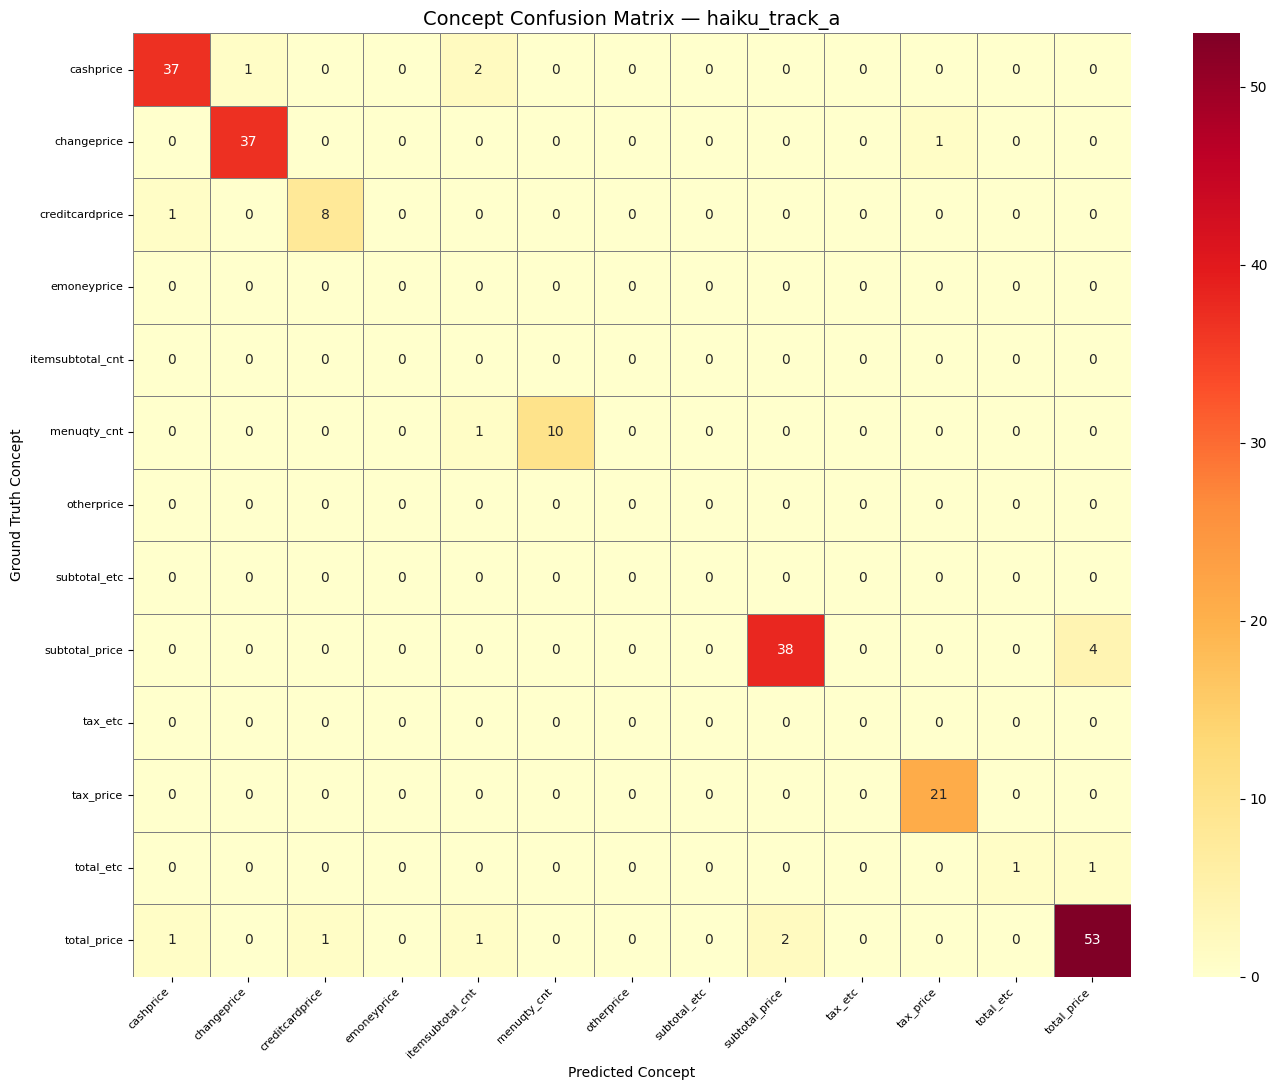


Top confusions (haiku_track_a):
     GT Concept     Pred Concept  Count Same Family?
 subtotal_price      total_price      4          Yes
      cashprice itemsubtotal_cnt      2           No
    total_price   subtotal_price      2          Yes
      cashprice      changeprice      1          Yes
    changeprice        tax_price      1           No
creditcardprice        cashprice      1          Yes
    menuqty_cnt itemsubtotal_cnt      1          Yes
      total_etc      total_price      1          Yes
    total_price        cashprice      1           No
    total_price  creditcardprice      1           No

CONFUSION MATRIX — haiku_track_b (LLM Vision)


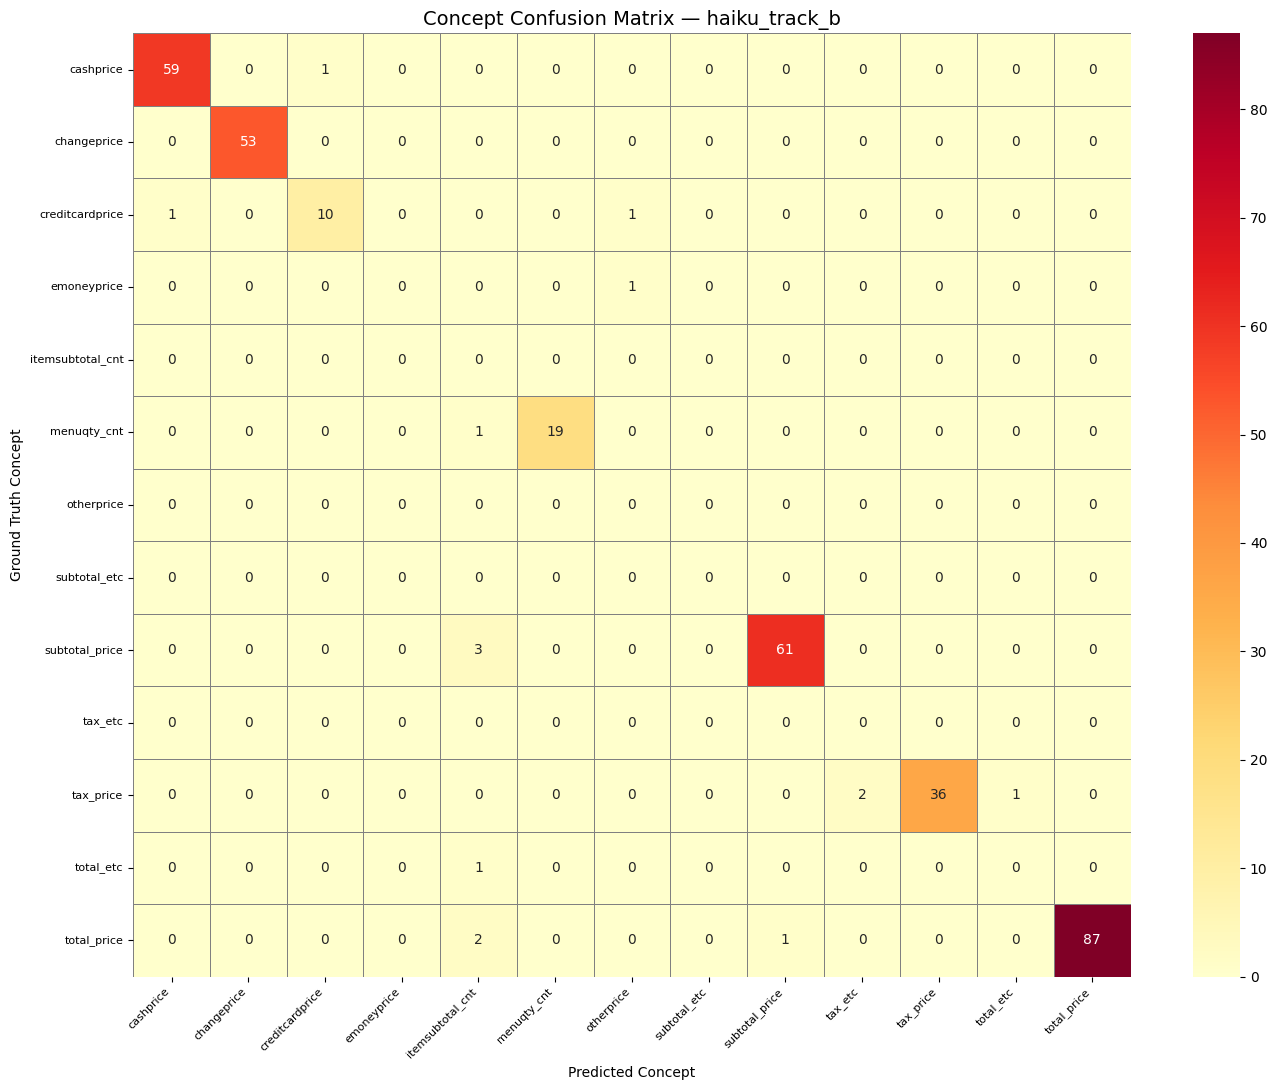


Top confusions (haiku_track_b):
     GT Concept     Pred Concept  Count Same Family?
 subtotal_price itemsubtotal_cnt      3           No
      tax_price          tax_etc      2          Yes
    total_price itemsubtotal_cnt      2           No
      cashprice  creditcardprice      1          Yes
creditcardprice        cashprice      1          Yes
creditcardprice       otherprice      1          Yes
    emoneyprice       otherprice      1          Yes
    menuqty_cnt itemsubtotal_cnt      1          Yes
      tax_price        total_etc      1          Yes
      total_etc itemsubtotal_cnt      1           No

CONFUSION MATRIX — gpt4o-mini_track_a (Tesseract+LLM)


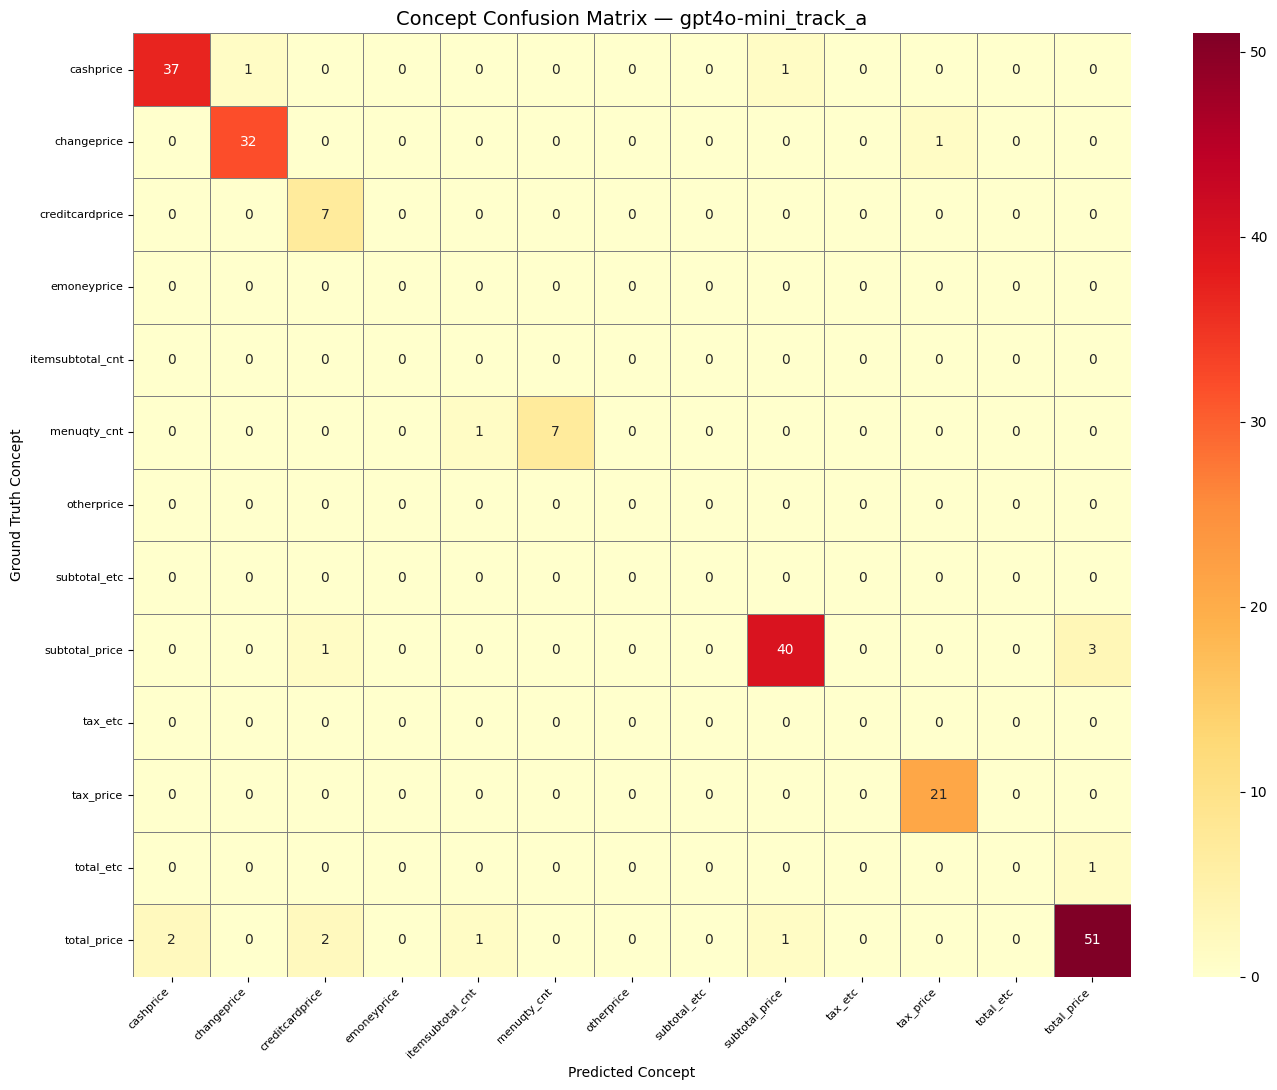


Top confusions (gpt4o-mini_track_a):
    GT Concept     Pred Concept  Count Same Family?
subtotal_price      total_price      3          Yes
   total_price        cashprice      2           No
   total_price  creditcardprice      2           No
     cashprice      changeprice      1          Yes
     cashprice   subtotal_price      1           No
   changeprice        tax_price      1           No
   menuqty_cnt itemsubtotal_cnt      1          Yes
subtotal_price  creditcardprice      1           No
     total_etc      total_price      1          Yes
   total_price itemsubtotal_cnt      1           No

CONFUSION MATRIX — gpt4o-mini_track_b (LLM Vision)


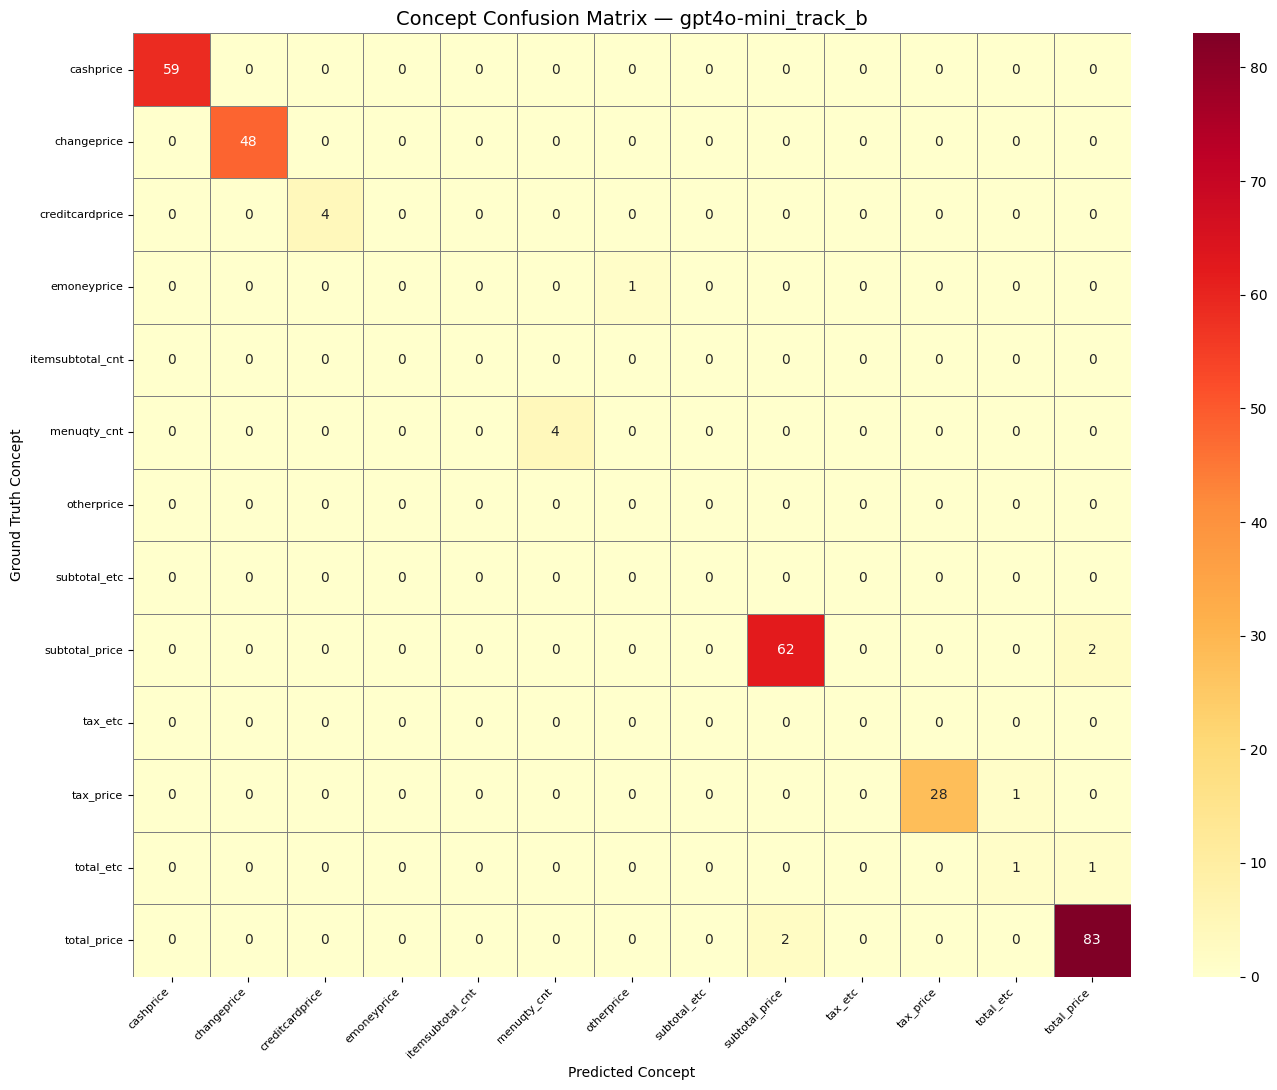


Top confusions (gpt4o-mini_track_b):
    GT Concept   Pred Concept  Count Same Family?
subtotal_price    total_price      2          Yes
   total_price subtotal_price      2          Yes
   emoneyprice     otherprice      1          Yes
     tax_price      total_etc      1          Yes
     total_etc    total_price      1          Yes

EXPECTED CONFUSION PAIRS — Cross-config summary
              GT             Pred  haiku_track_a  haiku_track_b  gpt4o-mini_track_a  gpt4o-mini_track_b
  subtotal_price      total_price              4              0                   3                   2
     total_price   subtotal_price              2              1                   1                   2
       cashprice      changeprice              1              0                   1                   0
     changeprice        cashprice              0              0                   0                   0
       cashprice      total_price              0              0                   0          

In [9]:
# Cell 9: Confusion Matrix

import numpy as np

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOT = True
except ImportError:
    HAS_PLOT = False

for config_key, results in experiments.items():
    print(f"\n{'='*60}")
    print(f"CONFUSION MATRIX — {config_key} ({results['track_name']})")
    print(f"{'='*60}")

    scored_docs = results["per_document"]
    cm_data = build_confusion_matrix(scored_docs)

    # Filter to only EVAL_CONCEPTS for cleaner display
    eval_idx = [i for i, c in enumerate(cm_data["concepts"]) if c in EVAL_CONCEPTS]
    eval_concepts_sorted = [cm_data["concepts"][i] for i in eval_idx]
    matrix_np = np.array(cm_data["matrix"])
    filtered_matrix = matrix_np[np.ix_(eval_idx, eval_idx)]

    df_cm = pd.DataFrame(
        filtered_matrix,
        index=eval_concepts_sorted,
        columns=eval_concepts_sorted
    )

    if HAS_PLOT:
        fig, ax = plt.subplots(figsize=(14, 11))
        sns.heatmap(
            df_cm, annot=True, fmt="d", cmap="YlOrRd", ax=ax,
            linewidths=0.5, linecolor="gray",
            xticklabels=True, yticklabels=True,
        )
        ax.set_title(f"Concept Confusion Matrix — {config_key}", fontsize=14)
        ax.set_xlabel("Predicted Concept")
        ax.set_ylabel("Ground Truth Concept")
        plt.xticks(rotation=45, ha="right", fontsize=8)
        plt.yticks(fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print(df_cm.to_string())

    # Top confusions
    print(f"\nTop confusions ({config_key}):")
    top = top_confusions(cm_data, n=10)
    if top:
        top_rows = []
        for gt_c, pred_c, count in top:
            gt_fam = concept_to_family.get(gt_c, "unknown")
            pred_fam = concept_to_family.get(pred_c, "unknown")
            top_rows.append({
                "GT Concept": gt_c,
                "Pred Concept": pred_c,
                "Count": count,
                "Same Family?": "Yes" if gt_fam == pred_fam else "No",
            })
        df_top = pd.DataFrame(top_rows)
        print(df_top.to_string(index=False))
    else:
        print("  No off-diagonal confusions.")

# --- Highlight expected confusion pairs ---
print(f"\n{'='*60}")
print("EXPECTED CONFUSION PAIRS — Cross-config summary")
print(f"{'='*60}")

expected_pairs = [
    ("subtotal_price", "total_price"),
    ("total_price", "subtotal_price"),
    ("cashprice", "changeprice"),
    ("changeprice", "cashprice"),
    ("cashprice", "total_price"),
    ("menuqty_cnt", "itemsubtotal_cnt"),
    ("itemsubtotal_cnt", "menuqty_cnt"),
    ("tax_price", "total_etc"),
]

pair_summary_rows = []
for gt_c, pred_c in expected_pairs:
    row = {"GT": gt_c, "Pred": pred_c}
    for config_key, results in experiments.items():
        count = sum(1 for mb in results["misbinding_log"]
                    if mb["gt_concept"] == gt_c and mb["pred_concept"] == pred_c)
        row[config_key] = count
    pair_summary_rows.append(row)

df_expected = pd.DataFrame(pair_summary_rows)
print(df_expected.to_string(index=False))

In [10]:
# Cell 10: Export Results

RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Collect all misbindings across configs
all_misbinding_log = []
for config_key, results in experiments.items():
    all_misbinding_log.extend(results["misbinding_log"])

# Build combined confusion matrix for export
all_scored_docs = []
for config_key, results in experiments.items():
    all_scored_docs.extend(results["per_document"])
combined_cm = build_confusion_matrix(all_scored_docs)

# Sample outputs for export (first 5 per config)
stage1_samples = {}
stage2_samples = {}
for config_key, results in experiments.items():
    stage1_samples[config_key] = [
        {"receipt_id": s["receipt_id"], "n_lines": s["n_lines"], "ocr_text": s["ocr_text"]}
        for s in results["stage1_raw_outputs"][:5]
    ]
    stage2_samples[config_key] = [
        {"receipt_id": s["receipt_id"], "n_mappings": s["n_mappings"], "mappings": s["mappings"]}
        for s in results["stage2_raw_outputs"][:5]
    ]

# Build exportable results
export_results = {
    "experiment": "hindsight_cord_cba",
    "dataset": "naver-clova-ix/cord-v2 (test split)",
    "prompt_design": "dual-track-array-output",
    "scoring": "value-first-matching",
    "date": datetime.now().strftime("%Y-%m-%d"),
    "description": (
        "Dual-track receipt concept binding on CORD. "
        "Track A: Tesseract OCR → LLM text mapping. "
        "Track B: LLM Vision direct extraction. "
        "Array output {label,value,concept}. Value-first scoring detects misbindings."
    ),
    "sample_size": len(sampled),
    "total_corpus": len(cord_data),
    "qualified_receipts": len(qualified),
    "eval_concepts": EVAL_CONCEPTS,
    "ontology": RECEIPT_ONTOLOGY,
    "tracks": {"track_a": "Tesseract+LLM", "track_b": "LLM Vision"},
    "models": {
        model_name: {"model_id": cfg["model_id"], "provider": cfg["provider"]}
        for model_name, cfg in MODELS.items()
    },
    "results": {
        config_key: {
            "model": results["model_name"],
            "track": results["track_name"],
            "field_recall": results["field_recall"],
            "cba_strict": results["cba_strict"],
            "cba_soft": results["cba_soft"],
            "delta": results["delta"],
            "n_documents": results["n_documents"],
            "total_misbindings": results["total_misbindings"],
            "errors": len(results["errors"]),
            "per_document_summary": [
                {
                    "receipt_id": d["receipt_id"],
                    "cord_index": d["cord_index"],
                    "field_recall": d["field_recall"],
                    "cba_strict": d["cba_strict"],
                    "cba_soft": d["cba_soft"],
                    "delta": d["delta"],
                    "n_misbindings": d["n_misbindings"],
                    "predictions": d["predictions"],
                    "gt": d["gt"],
                }
                for d in results["per_document"]
            ],
        }
        for config_key, results in experiments.items()
    },
    "stage1_ocr_samples": stage1_samples,
    "stage2_mapping_samples": stage2_samples,
    "misbinding_log": all_misbinding_log,
    "confusion_matrix": {
        "concepts": combined_cm["concepts"],
        "matrix": combined_cm["matrix"],
        "families": combined_cm["families"],
    },
}

output_path = os.path.join(RESULTS_DIR, "hindsight_cord_cba_results.json")
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(export_results, f, indent=2, default=str)

print(f"Results exported to: {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024:.1f} KB")

# Final summary
print(f"\n{'='*70}")
print("EXPERIMENT SUMMARY — CORD CBA (Dual-Track, Value-First Scoring)")
print(f"{'='*70}")
print(f"Dataset: CORD v2 (Indonesian receipts)")
print(f"Sample size: {len(sampled)} / {len(qualified)} qualified / {len(cord_data)} total")
print(f"Concepts evaluated: {len(EVAL_CONCEPTS)}")
print(f"Tracks: A (Tesseract+LLM), B (LLM Vision)")

for config_key, results in experiments.items():
    print(f"\n{config_key} ({results['track_name']}):")
    print(f"  Field Recall:       {results['field_recall']:.4f}")
    print(f"  CBA-strict:     {results['cba_strict']:.4f}")
    print(f"  CBA-soft:       {results['cba_soft']:.4f}")
    print(f"  Delta (F1-CBA): {results['delta']:.4f}")
    print(f"  Misbindings:    {results['total_misbindings']}")
    kill_signal = results['delta'] >= 0.05
    print(f"  Kill signal:    {'YES (delta >= 5%)' if kill_signal else 'No (delta < 5%)'}")

total_misbindings = sum(r["total_misbindings"] for r in experiments.values())
print(f"\nTotal misbindings across all configs: {total_misbindings}")

Results exported to: /content/../results/hindsight_cord_cba_results.json
File size: 232.9 KB

EXPERIMENT SUMMARY — CORD CBA (Dual-Track, Value-First Scoring)
Dataset: CORD v2 (Indonesian receipts)
Sample size: 93 / 93 qualified / 100 total
Concepts evaluated: 13
Tracks: A (Tesseract+LLM), B (LLM Vision)

haiku_track_a (Tesseract+LLM):
  Field F1:       0.4822
  CBA-strict:     0.5812
  CBA-soft:       0.5946
  Delta (F1-CBA): -0.0989
  Misbindings:    16
  Kill signal:    No (delta < 5%)

haiku_track_b (LLM Vision):
  Field F1:       0.8832
  CBA-strict:     0.9022
  CBA-soft:       0.9171
  Delta (F1-CBA): -0.0190
  Misbindings:    15
  Kill signal:    No (delta < 5%)

gpt4o-mini_track_a (Tesseract+LLM):
  Field F1:       0.3853
  CBA-strict:     0.5455
  CBA-soft:       0.5553
  Delta (F1-CBA): -0.1602
  Misbindings:    15
  Kill signal:    No (delta < 5%)

gpt4o-mini_track_b (LLM Vision):
  Field F1:       0.8077
  CBA-strict:     0.8111
  CBA-soft:       0.8218
  Delta (F1-CBA): -0

In [11]:
# Cell 11: Diagnostic — Why is Delta Negative?
#
# Delta = F1 - CBA. Negative delta means CBA > F1, i.e., the model binds
# concepts correctly more often than it extracts values correctly.
#
# This cell investigates: are value mismatches real extraction failures,
# or normalization artifacts where the value IS correct but normalize_value()
# doesn't equate them?

print("=" * 80)
print("DIAGNOSTIC: VALUE MISMATCH ANALYSIS (Track B only — cleaner signal)")
print("=" * 80)

# Focus on Track B (Vision) where F1 is high enough to matter
for config_key in ["haiku_track_b", "gpt4o-mini_track_b"]:
    results = experiments[config_key]
    print(f"\n{'='*70}")
    print(f"{config_key}")
    print(f"{'='*70}")

    # Categorize every GT field into one of 4 buckets
    correct = []        # value match + concept match
    misbinding = []     # value match + concept WRONG
    value_miss = []     # value WRONG + concept present
    total_miss = []     # concept not in predictions at all

    for doc in results["per_document"]:
        gt = doc.get("gt", {})
        preds = doc.get("predictions", {})
        receipt_id = doc["receipt_id"]

        for field in doc["per_field"]:
            gt_c = field["gt_concept"]
            pred_c = field["pred_concept"]
            gt_v = field["gt_value"]
            pred_v = field["pred_value"]
            norm_gt = normalize_value(gt_v)
            norm_pred = normalize_value(pred_v)

            entry = {
                "receipt": receipt_id,
                "concept": gt_c,
                "gt_val": gt_v,
                "pred_val": pred_v,
                "norm_gt": norm_gt,
                "norm_pred": norm_pred,
                "pred_concept": pred_c,
            }

            if field["value_match"] and field["cba_strict"] == 1.0:
                correct.append(entry)
            elif field["is_misbinding"]:
                misbinding.append(entry)
            elif pred_c == "__MISSING__":
                total_miss.append(entry)
            else:
                value_miss.append(entry)

    total = len(correct) + len(misbinding) + len(value_miss) + len(total_miss)
    print(f"\nField breakdown ({total} total GT fields):")
    print(f"  Correct (value + concept):  {len(correct):3d} ({100*len(correct)/total:.1f}%)")
    print(f"  Misbinding (value ok, concept wrong): {len(misbinding):3d} ({100*len(misbinding)/total:.1f}%)")
    print(f"  Value miss (concept ok, value wrong):  {len(value_miss):3d} ({100*len(value_miss)/total:.1f}%)")
    print(f"  Total miss (concept not predicted):    {len(total_miss):3d} ({100*len(total_miss)/total:.1f}%)")

    # Value misses are what drive negative delta — inspect them
    print(f"\n--- VALUE MISSES ({len(value_miss)} cases) ---")
    print(f"These are cases where the model mapped to the RIGHT concept")
    print(f"but the value didn't match after normalization.\n")

    # Categorize value misses by pattern
    patterns = Counter()
    near_misses = []

    for m in value_miss:
        gt = m["norm_gt"]
        pred = m["norm_pred"]

        if pred == "":
            patterns["empty_prediction"] += 1
        elif gt in pred or pred in gt:
            patterns["substring_match"] += 1
            near_misses.append(m)
        elif gt.replace(".", "") == pred.replace(".", ""):
            patterns["dot_format_diff"] += 1
            near_misses.append(m)
        elif gt.replace(" ", "") == pred.replace(" ", ""):
            patterns["whitespace_diff"] += 1
            near_misses.append(m)
        elif abs(len(gt) - len(pred)) <= 2 and len(gt) > 3:
            patterns["minor_ocr_diff"] += 1
            near_misses.append(m)
        else:
            patterns["major_diff"] += 1

    print(f"Pattern distribution:")
    for pattern, count in patterns.most_common():
        print(f"  {pattern}: {count}")

    print(f"\n  Near misses (fixable with better normalization): {len(near_misses)}")
    print(f"  If fixed, F1 would increase by ~{len(near_misses)/total:.3f}")

    # Show first 30 value misses with details
    print(f"\n--- Sample value misses ---")
    for m in value_miss[:30]:
        flag = " *** NEAR MISS" if m in near_misses else ""
        print(f"  [{m['receipt']}] {m['concept']}")
        print(f"    GT:   '{m['gt_val']}' → '{m['norm_gt']}'")
        print(f"    Pred: '{m['pred_val']}' → '{m['norm_pred']}'{flag}")

    # Show total misses too (concept not predicted)
    print(f"\n--- TOTAL MISSES ({len(total_miss)} cases — concept not in predictions) ---")
    miss_by_concept = Counter(m["concept"] for m in total_miss)
    for concept, count in miss_by_concept.most_common():
        print(f"  {concept}: {count}")

# --- Summary: can we flip delta? ---
print(f"\n{'='*80}")
print("SUMMARY: Can normalization fixes flip delta positive?")
print(f"{'='*80}")
for config_key in ["haiku_track_b", "gpt4o-mini_track_b"]:
    results = experiments[config_key]
    # Recount
    n_near = 0
    n_total_fields = 0
    for doc in results["per_document"]:
        for field in doc["per_field"]:
            n_total_fields += 1
            if not field["value_match"] and field["pred_concept"] != "__MISSING__" and field["cba_strict"] == 1.0:
                gt = normalize_value(field["gt_value"])
                pred = normalize_value(field["pred_value"])
                if (gt in pred or pred in gt or
                    gt.replace(".", "") == pred.replace(".", "") or
                    gt.replace(" ", "") == pred.replace(" ", "")):
                    n_near += 1
    current_delta = results["delta"]
    potential_delta = current_delta + n_near / n_total_fields
    print(f"\n  {config_key}:")
    print(f"    Current delta: {current_delta:+.4f}")
    print(f"    Near misses fixable: {n_near}")
    print(f"    Potential delta if fixed: {potential_delta:+.4f}")
    print(f"    Would flip positive? {'YES' if potential_delta > 0 else 'No'}")

DIAGNOSTIC: VALUE MISMATCH ANALYSIS (Track B only — cleaner signal)

haiku_track_b

Field breakdown (360 total GT fields):
  Correct (value + concept):  302 (83.9%)
  Misbinding (value ok, concept wrong):  15 (4.2%)
  Value miss (concept ok, value wrong):   23 (6.4%)
  Total miss (concept not predicted):     20 (5.6%)

--- VALUE MISSES (23 cases) ---
These are cases where the model mapped to the RIGHT concept
but the value didn't match after normalization.

Pattern distribution:
  minor_ocr_diff: 17
  substring_match: 3
  major_diff: 2
  whitespace_diff: 1

  Near misses (fixable with better normalization): 21
  If fixed, F1 would increase by ~0.058

--- Sample value misses ---
  [receipt_0007] cashprice
    GT:   'Rp. 111,000' → '. 111000'
    Pred: 'Rp.111,000' → '.111000' *** NEAR MISS
  [receipt_0013] subtotal_price
    GT:   '46.636' → '46636'
    Pred: '46,000' → '46000' *** NEAR MISS
  [receipt_0013] tax_price
    GT:   '4.664' → '4664'
    Pred: '4,600' → '4600' *** NEAR MISS
 